# Part 6 — Wilson-Cowan E/I Circuit Model

Fits a two-population Wilson-Cowan firing-rate model to RSU (E population)
and FSU (I population) temporal dynamics. The key parameter is
r_EI = w_EE / w_IE. The primary analysis fits the model to RSU pools
subsampled to each session's own FSU count (matched-count RSU, not
subsampled FSU), for three targets in turn — cross-mouse consistency,
total firing rate, and image-selective firing-rate amplitude — and
cross-validates over sessions. Fits to the full, unsubsampled RSU pool are
reported as a validation check.

**Depends on:** `part3_outputs.npz`, `part5_outputs.npz`, `responses.h5`, `units_meta.parquet`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve()))
from utils import (
    setup_archive,
    window_response,
    compute_similarity_matrices,
    per_image_consistency,
    cluster_bootstrap_ci,
    apply_plot_style,
    ts_ratio,
    print_figure_data,
)

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.integrate import odeint
from scipy.optimize import minimize
from scipy.stats import gamma as gamma_dist
from sklearn.model_selection import KFold

SEED = 42
rng  = np.random.default_rng(SEED)

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 9.5, 'figure.dpi': 150,
})
sns.set_style('ticks')

colors   = apply_plot_style()
COL_DATA = colors["COL_DATA"]            # train split / matched (primary)
COL_TEST = colors["COL_TEST"]            # test split / full-pool (validation)
COL_RSU  = colors["COL_RSU"]             # RSU / E population — same category as Part 5
COL_FSU  = colors["COL_FSU"]             # FSU / I population — same category as Part 5
COL_FIT  = colors["COL_FIT"]             # fitted model curves / annotations
COL_REF  = colors["COL_REF"]
COL_REI  = colors["COL_REI"]             # r_EI parameter (own dedicated quantity)
COL_INFORMED_START = colors["COL_INFORMED_START"]   # informed-start robustness check
COL_TARGET_CONSISTENCY = colors["COL_TARGET_CONSISTENCY"]  # fit target: consistency
COL_TARGET_TOTAL_RATE  = colors["COL_TARGET_TOTAL_RATE"]   # fit target: total rate
COL_TARGET_SELECTIVE   = colors["COL_TARGET_SELECTIVE"]    # fit target: selective amplitude

In [2]:
# Load archive, extract if needed, resolve output paths.
manifest, bin_edges, ARCHIVE_DIR, FIGURES_DIR, OUTPUTS_DIR = setup_archive(
    zip_path    = '../preprocessed_data.zip',
    archive_dir = '../preprocessed_data',
    figures_dir = '../figures',
    outputs_dir = '.',
)

p3 = np.load(OUTPUTS_DIR / 'part3_outputs.npz')
WINDOW_WIDTH_MS = float(p3['window_width_ms'])   # same window width used to build ts_rsu/ts_fsu

p5 = np.load(OUTPUTS_DIR / 'part5_outputs.npz', allow_pickle=True)
ts_rsu       = p5['ts_rsu'].astype(float)
mc_rsu_full  = p5['mc_rsu'].astype(float)     # full (unsubsampled) RSU pool -- validation target
ts_fsu       = p5['ts_fsu'].astype(float)
mc_fsu       = p5['mc_fsu'].astype(float)     # FSU is never subsampled -- same in both analyses

# Sessions where both classes met Part 5's MIN_UNITS_SUBPOP threshold in the
# same session (identical sets by construction -- Part 5 requires both).
rsu_sids = p5['rsu_sids'].tolist()
fsu_sids = p5['fsu_sids'].tolist()

# Reuse Part 5's exact per-unit GMM classification (RSU/FSU/ambiguous), so the
# E/I populations modeled here match the subpopulations analysed in Part 5.
unit_class = pd.DataFrame({
    'ecephys_session_id': p5['unit_class_session_id'],
    'unit_id':             p5['unit_class_unit_id'],
    'cell_class':          p5['unit_class_label'],
})

print(f'RSU curve: {len(ts_rsu)} windows, peak = {mc_rsu_full.max():.3f}')
print(f'FSU curve: {len(ts_fsu)} windows, peak = {mc_fsu.max():.3f}')
print(f'Shared sessions (both classes >= threshold): {len(rsu_sids)}')

Archive already extracted: C:\Users\janak\GitHub\cross-mouse-v1-rsa\preprocessed_data
Manifest: 32 VISp sessions | 118 images | 479 bins × 1 ms
RSU curve: 43 windows, peak = 0.267
FSU curve: 43 windows, peak = 0.277
Shared sessions (both classes >= threshold): 9


## 6.1 — Wilson-Cowan E/I model definition

The model is reparameterized with r_EI = w_EE / w_IE as an explicit free
parameter (bounded [0.01, 2.0]), separating the identifiable quantity of
interest from the overall inhibitory scale (w_IE), which is a nuisance
parameter. r_EI < 1 = inhibition-dominated; r_EI > 1 = recurrence-dominated.

Time constants are fixed at biologically motivated values (τ_E = 20 ms,
τ_I = 10 ms). The thalamic drive D(t) is a gamma-shaped function with
onset at 40 ms, shared by both populations.

In [3]:
# ── Thalamic drive (gamma-shaped, onset 40 ms) ────────────────────────────────
_ONSET  = 40.0
_K      = 5.0
_THETA  = 14.0
_NORM   = gamma_dist.pdf((_K - 1) * _THETA, a=_K, scale=_THETA) + 1e-8

def thalamic_drive(t_ms, amp):
    t_s = t_ms - _ONSET
    if t_s <= 0:
        return 0.0
    return amp * gamma_dist.pdf(t_s, a=_K, scale=_THETA) / _NORM

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -20, 20)))


# ── Reparameterized Wilson-Cowan ODE ─────────────────────────────────────────
#  dE/dt = (−E + σ(r_EI·w_IE·E − w_IE·I + D(t)))   / τ_E
#  dI/dt = (−I + σ(w_EI·E     − w_II·I + 0.7·D(t))) / τ_I
TAU_E = 20.0   # ms — fixed
TAU_I = 10.0   # ms — fixed

def ei_ode(y, t_ms, r_EI, w_IE, w_EI, w_II, I_amp):
    E, I  = y
    D     = thalamic_drive(t_ms, I_amp)
    dE = (-E + sigmoid(r_EI * w_IE * E - w_IE * I + D))       / TAU_E
    dI = (-I + sigmoid(w_EI         * E - w_II * I + 0.7 * D)) / TAU_I
    return [dE, dI]

def simulate(params, t_eval_ms):
    r_EI, w_IE, w_EI, w_II, I_amp = params
    sol = odeint(ei_ode, [0.01, 0.01], t_eval_ms,
                 args=(r_EI, w_IE, w_EI, w_II, I_amp),
                 rtol=1e-6, atol=1e-8)
    return sol[:, 0], sol[:, 1]   # E, I trajectories


BOUNDS = [
    (0.01, 2.0),    # r_EI  — KEY PARAMETER
    (0.1,  20.0),   # w_IE
    (0.1,  15.0),   # w_EI
    (0.0,   8.0),   # w_II
    (0.5,  20.0),   # I_amp
]
x0_informed = np.array([0.65, 10.0, 4.0, 4.0, 10.0])

def r2_score(y, yhat):
    return 1 - np.sum((y - yhat)**2) / np.sum((y - y.mean())**2)

def prep_curves(ts_r, mc_r, ts_f, mc_f):
    """Restrict to the 0-250 ms post-stimulus clean window and normalise each
    curve to [0, 1] for fitting."""
    clean_r = (ts_r >= 0) & (ts_r <= 250)
    clean_f = (ts_f >= 0) & (ts_f <= 250)
    t_r, c_r = ts_r[clean_r], mc_r[clean_r]
    t_f, c_f = ts_f[clean_f], mc_f[clean_f]
    c_r_n = (c_r - c_r.min()) / (c_r.max() - c_r.min() + 1e-8)
    c_f_n = (c_f - c_f.min()) / (c_f.max() - c_f.min() + 1e-8)
    return t_r, c_r, c_r_n, t_f, c_f, c_f_n

def fit_wc_model(target_rsu, target_fsu, seed_rng, n_restarts=9):
    """Fit the E/I model to a (RSU, FSU) curve pair: one informed start plus
    n_restarts random starts, keeping the lowest-loss result. Used for every
    fit target (matched and full) so all fits share identical optimisation
    settings."""
    t_a, a_r, a_r_n, t_b, a_f, a_f_n = prep_curves(ts_rsu, target_rsu, ts_fsu, target_fsu)

    def loss_fn(params):
        try:
            E, I = simulate(params, t_a)
            E_n  = (E - E.min()) / (E.max() - E.min() + 1e-8)
            I_n  = (I - I.min()) / (I.max() - I.min() + 1e-8)
            return np.mean((E_n - a_r_n)**2) + np.mean((I_n - a_f_n)**2)
        except Exception:
            return 1e6

    starts = [x0_informed] + [
        seed_rng.uniform([b[0] for b in BOUNDS], [b[1] for b in BOUNDS])
        for _ in range(n_restarts)
    ]

    best, stab = None, []
    for x0 in starts:
        try:
            res = minimize(loss_fn, x0, method='L-BFGS-B', bounds=BOUNDS,
                           options={'maxiter': 3000, 'ftol': 1e-13, 'gtol': 1e-9})
            stab.append(res.x[0])
            if best is None or res.fun < best.fun:
                best = res
        except Exception:
            pass
    stab = np.array(stab)

    E_fit, I_fit = simulate(best.x, t_a)
    E_sc = E_fit * (a_r.max() - a_r.min()) + a_r.min()
    I_sc = I_fit * (a_f.max() - a_f.min()) + a_f.min()
    return dict(t=t_a, data_r=a_r, data_f=a_f, E_sc=E_sc, I_sc=I_sc,
                r_EI=best.x[0], stab=stab, r2_E=r2_score(a_r, E_sc), r2_I=r2_score(a_f, I_sc),
                success=best.success, params=best.x)

print('Model defined.  τ_E =', TAU_E, 'ms,  τ_I =', TAU_I, 'ms')

Model defined.  τ_E = 20.0 ms,  τ_I = 10.0 ms


## 6.2 — Firing-rate PSTHs (full, unsubsampled pools)

Computes population firing-rate curves for the RSU and FSU pools directly
from the raw spike-count tensors (`responses.h5`), using Part 5's exact
unit classification and session sets. Two variants are computed: total
firing rate (summed across images and units) and image-selective
amplitude (per-unit standard deviation of firing rate across images,
averaged over the pool) — the latter matches the per-unit z-scoring
applied in `window_response()` before consistency is computed. These full
pools are also retained per-session (not just pool-averaged) for reuse in
cross-validation below.

In [4]:
print('Loading VISp tensors for firing-rate PSTHs...')
rate_tensors = {}
with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for sid in sorted(set(rsu_sids) | set(fsu_sids)):
        grp = f[f'natural_scenes/VISp/{sid}']
        rate_tensors[sid] = {
            'tensor':   grp['tensor'][:],
            'unit_ids': grp['unit_ids'][:],
        }
print('Done.')

def session_unit_idx(sid, cls):
    uid_arr = rate_tensors[sid]['unit_ids']
    keep = set(unit_class.loc[(unit_class['ecephys_session_id'] == sid) &
                               (unit_class['cell_class'] == cls), 'unit_id'])
    return [i for i, uid in enumerate(uid_arr) if uid in keep]

rate_rsu_idx = {sid: session_unit_idx(sid, 'RSU') for sid in rsu_sids}
rate_fsu_idx = {sid: session_unit_idx(sid, 'FSU') for sid in fsu_sids}


def session_rate_curve(tensor, unit_idx, window_centers_ms, width_ms, bin_edges):
    """Mean per-unit, per-image firing rate (Hz) in each sliding window."""
    n_images = tensor.shape[0]
    n_units  = len(unit_idx)
    rates = np.zeros(len(window_centers_ms))
    for k, t_ms in enumerate(window_centers_ms):
        lo = np.searchsorted(bin_edges, t_ms - width_ms / 2)
        hi = np.searchsorted(bin_edges, t_ms + width_ms / 2)
        window_s = (hi - lo) * (bin_edges[1] - bin_edges[0]) / 1000.0
        rates[k] = tensor[:, unit_idx, lo:hi].sum() / (n_images * n_units * window_s)
    return rates


def session_selectivity_curve(tensor, unit_idx, window_centers_ms, width_ms, bin_edges):
    """Image-selective response amplitude (Hz): per-unit std of firing rate
    across images, averaged over the unit pool. A non-selective onset burst
    that is identical for every image contributes ~0 here (std ~ 0), the same
    way it is removed by the per-unit z-scoring in window_response() before
    the consistency curves are computed."""
    n_units = len(unit_idx)
    curve = np.zeros(len(window_centers_ms))
    for k, t_ms in enumerate(window_centers_ms):
        lo = np.searchsorted(bin_edges, t_ms - width_ms / 2)
        hi = np.searchsorted(bin_edges, t_ms + width_ms / 2)
        window_s = (hi - lo) * (bin_edges[1] - bin_edges[0]) / 1000.0
        counts_hz = tensor[:, unit_idx, lo:hi].sum(axis=2) / window_s   # (n_images, n_units)
        curve[k]  = counts_hz.std(axis=0).mean()
    return curve


rate_curves_rsu_full = np.array([
    session_rate_curve(rate_tensors[sid]['tensor'], rate_rsu_idx[sid], ts_rsu, WINDOW_WIDTH_MS, bin_edges)
    for sid in rsu_sids
])
rate_curves_fsu = np.array([
    session_rate_curve(rate_tensors[sid]['tensor'], rate_fsu_idx[sid], ts_fsu, WINDOW_WIDTH_MS, bin_edges)
    for sid in fsu_sids
])
sel_curves_rsu_full = np.array([
    session_selectivity_curve(rate_tensors[sid]['tensor'], rate_rsu_idx[sid], ts_rsu, WINDOW_WIDTH_MS, bin_edges)
    for sid in rsu_sids
])
sel_curves_fsu = np.array([
    session_selectivity_curve(rate_tensors[sid]['tensor'], rate_fsu_idx[sid], ts_fsu, WINDOW_WIDTH_MS, bin_edges)
    for sid in fsu_sids
])

rate_rsu_full = rate_curves_rsu_full.mean(axis=0)   # (n_windows,) Hz, full RSU pool
rate_fsu      = rate_curves_fsu.mean(axis=0)        # FSU never subsampled -- same in both analyses
sel_rsu_full  = sel_curves_rsu_full.mean(axis=0)
sel_fsu       = sel_curves_fsu.mean(axis=0)

print(f'RSU (full pool)  — mean {np.mean([len(v) for v in rate_rsu_idx.values()]):.1f} units/session')
print(f'FSU               — mean {np.mean([len(v) for v in rate_fsu_idx.values()]):.1f} units/session')

Loading VISp tensors for firing-rate PSTHs...
Done.
RSU (full pool)  — mean 62.6 units/session
FSU               — mean 16.2 units/session


## 6.3 — Matched-count sampling: RSU subsampled to each session's own FSU count

RSU sessions have far more units than FSU sessions on average, which
inflates similarity-matrix SNR (for consistency) and pool-averaged rate
statistics independently of any genuine cell-type effect. To build a
primary set of fit targets free of this confound, each RSU session's unit
pool is subsampled down to that same session's own FSU count, over 50
draws; the identical drawn subsample is used to compute all three target
quantities (consistency, total rate, and selective amplitude) for that
draw, so a single consistent "matched RSU" population underlies every fit
target. FSU pools are never subsampled (already the smaller class). Draws
are retained per-session (not just pool-averaged) for reuse in
cross-validation.

In [5]:
N_DRAWS_MATCH   = 50
target_n_by_sid = {sid: len(rate_fsu_idx[sid]) for sid in fsu_sids}
rng_match       = np.random.default_rng(SEED)

n_windows       = len(ts_rsu)
n_rsu_sessions  = len(rsu_sids)

consist_draws = np.zeros((N_DRAWS_MATCH, n_windows))                  # pooled across sessions per draw
rate_draws    = np.zeros((N_DRAWS_MATCH, n_rsu_sessions, n_windows))  # per-session, for CV reuse
sel_draws     = np.zeros((N_DRAWS_MATCH, n_rsu_sessions, n_windows))

for d in range(N_DRAWS_MATCH):
    draw_idx = {
        sid: rng_match.choice(rate_rsu_idx[sid], size=target_n_by_sid[sid], replace=False)
        for sid in rsu_sids
    }

    for w, t_ms in enumerate(ts_rsu):
        t_lo = t_ms - WINDOW_WIDTH_MS / 2
        t_hi = t_ms + WINDOW_WIDTH_MS / 2
        mats = [window_response(rate_tensors[sid]['tensor'][:, draw_idx[sid], :], t_lo, t_hi, bin_edges)
                for sid in rsu_sids]
        sims = compute_similarity_matrices(mats)
        c, _, _ = per_image_consistency(sims)
        consist_draws[d, w] = c.mean()

    for s, sid in enumerate(rsu_sids):
        rate_draws[d, s] = session_rate_curve(rate_tensors[sid]['tensor'], draw_idx[sid],
                                               ts_rsu, WINDOW_WIDTH_MS, bin_edges)
        sel_draws[d, s]  = session_selectivity_curve(rate_tensors[sid]['tensor'], draw_idx[sid],
                                                      ts_rsu, WINDOW_WIDTH_MS, bin_edges)

mc_rsu_matched   = consist_draws.mean(axis=0)
rate_rsu_matched = rate_draws.mean(axis=(0, 1))
sel_rsu_matched  = sel_draws.mean(axis=(0, 1))

ts_ratio_matched, pk_matched, sus_matched = ts_ratio(mc_rsu_matched, ts_rsu)
ts_ratio_full,    pk_full,    sus_full    = ts_ratio(mc_rsu_full,    ts_rsu)
print(f'RSU consistency — matched: peak={pk_matched:.3f}, T/S={ts_ratio_matched:.2f}  |  '
      f'full: peak={pk_full:.3f}, T/S={ts_ratio_full:.2f}')

RSU consistency — matched: peak=0.132, T/S=2.02  |  full: peak=0.267, T/S=1.60


## 6.4 — Fit E/I model to matched-count targets (primary analysis)

The model is fit independently to three matched-count targets: cross-mouse
consistency, total firing rate, and image-selective firing-rate amplitude,
each computed with RSU subsampled to the matched FSU count as in §6.3.

In [6]:
fit_consistency_matched = fit_wc_model(mc_rsu_matched,   mc_fsu, rng)
fit_rate_matched        = fit_wc_model(rate_rsu_matched, rate_fsu, rng)
fit_sel_matched         = fit_wc_model(sel_rsu_matched,  sel_fsu, rng)

for name, fit in [('Consistency', fit_consistency_matched),
                   ('Total rate', fit_rate_matched),
                   ('Selective amplitude', fit_sel_matched)]:
    print(f'{name:>20s} (matched) — r_EI={fit["r_EI"]:.4f}  '
          f'R²(RSU)={fit["r2_E"]:.3f}  R²(FSU)={fit["r2_I"]:.3f}  '
          f'stability={fit["stab"].mean():.3f}±{fit["stab"].std():.3f}')

         Consistency (matched) — r_EI=0.6409  R²(RSU)=0.857  R²(FSU)=0.855  stability=0.641±0.000
          Total rate (matched) — r_EI=1.1124  R²(RSU)=0.769  R²(FSU)=0.456  stability=1.103±0.020
 Selective amplitude (matched) — r_EI=0.6198  R²(RSU)=0.900  R²(FSU)=0.887  stability=0.620±0.000


## 6.5 — T/S sensitivity: matched selective-amplitude fit

Varies r_EI and w_IE with the remaining parameters fixed at the matched
selective-amplitude fit's values, to characterise the T/S ratio's
dependence on r_EI within this model family.

In [7]:
r_EI_range = np.linspace(0.1, 2.0, 30)
w_IE_range = np.linspace(1.0, 15.0, 30)
ts_grid_sel = np.zeros((len(w_IE_range), len(r_EI_range)))

w_EI_sel, w_II_sel, I_amp_sel = fit_sel_matched['params'][2], fit_sel_matched['params'][3], fit_sel_matched['params'][4]
t_sel = fit_sel_matched['t']

for ii, w_IE in enumerate(w_IE_range):
    for jj, r_ei in enumerate(r_EI_range):
        p_test = [r_ei, w_IE, w_EI_sel, w_II_sel, I_amp_sel]
        try:
            E_t, _ = simulate(p_test, t_sel)
            sus_mask = (t_sel >= 220) & (t_sel <= 250)
            pk  = E_t.max()
            sus = E_t[sus_mask].mean() if sus_mask.any() else E_t[-1]
            ts_grid_sel[ii, jj] = pk / (sus + 1e-8)
        except Exception:
            ts_grid_sel[ii, jj] = np.nan

## 6.6 — Cross-validation: matched selective-amplitude fit

Five-fold cross-validation over the 9 shared sessions. Train/test matched
curves are built by averaging the §6.3 per-draw, per-session curves over
just the fold's sessions (reusing the same underlying random subsamples
rather than redrawing), so CV and the primary fit are based on identical
matched-sampling draws.

In [8]:
N_FOLDS = 5
sids_cv = rsu_sids   # == fsu_sids
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_results_sel = []
for fold_idx, (train_pos, test_pos) in enumerate(kf.split(np.arange(len(sids_cv)))):
    sel_r_train = sel_draws[:, train_pos, :].mean(axis=(0, 1))
    sel_r_test  = sel_draws[:, test_pos, :].mean(axis=(0, 1))
    sel_f_train = sel_curves_fsu[train_pos].mean(0)
    sel_f_test  = sel_curves_fsu[test_pos].mean(0)

    _, _, a_r_tr_n, _, _, a_f_tr_n = prep_curves(ts_rsu, sel_r_train, ts_fsu, sel_f_train)
    _, _, a_r_te_n, _, _, a_f_te_n = prep_curves(ts_rsu, sel_r_test,  ts_fsu, sel_f_test)

    def loss_fold(params, t_a=fit_sel_matched['t'], a_r_n=a_r_tr_n, a_f_n=a_f_tr_n):
        try:
            E, I = simulate(params, t_a)
            E_n  = (E - E.min()) / (E.max() - E.min() + 1e-8)
            I_n  = (I - I.min()) / (I.max() - I.min() + 1e-8)
            return np.mean((E_n - a_r_n)**2) + np.mean((I_n - a_f_n)**2)
        except Exception:
            return 1e6

    best_f = None
    for x0_ in [
        fit_sel_matched['params'],
        np.clip(fit_sel_matched['params'] * rng.uniform(0.85, 1.15, size=5),
                [b[0] for b in BOUNDS], [b[1] for b in BOUNDS]),
        np.clip(fit_sel_matched['params'] * rng.uniform(0.70, 1.30, size=5),
                [b[0] for b in BOUNDS], [b[1] for b in BOUNDS]),
    ]:
        try:
            res = minimize(loss_fold, x0_, method='L-BFGS-B', bounds=BOUNDS,
                           options={'maxiter': 2000, 'ftol': 1e-12})
            if best_f is None or res.fun < best_f.fun:
                best_f = res
        except Exception:
            pass

    E_fit_, _ = simulate(best_f.x, fit_sel_matched['t'])
    E_n_ = (E_fit_ - E_fit_.min()) / (E_fit_.max() - E_fit_.min() + 1e-8)
    r2_train_ = r2_score(a_r_tr_n, E_n_)
    r2_test_  = r2_score(a_r_te_n, E_n_)
    fold_results_sel.append({'fold': fold_idx + 1, 'r2_train': r2_train_,
                              'r2_test': r2_test_, 'r_EI': best_f.x[0]})
    print(f'Fold {fold_idx+1}: r_EI={best_f.x[0]:.3f}  R²_train={r2_train_:.3f}  R²_test={r2_test_:.3f}')

df_cv_sel = pd.DataFrame(fold_results_sel)
print(f'\nMean train R² : {df_cv_sel.r2_train.mean():.3f} ± {df_cv_sel.r2_train.std():.3f}')
print(f'Mean test  R² : {df_cv_sel.r2_test.mean():.3f} ± {df_cv_sel.r2_test.std():.3f}')
print(f'Mean r_EI     : {df_cv_sel.r_EI.mean():.3f} ± {df_cv_sel.r_EI.std():.3f}')

Fold 1: r_EI=0.647  R²_train=0.886  R²_test=0.791
Fold 2: r_EI=0.599  R²_train=0.889  R²_test=0.816
Fold 3: r_EI=0.654  R²_train=0.889  R²_test=0.809
Fold 4: r_EI=0.610  R²_train=0.866  R²_test=0.828
Fold 5: r_EI=0.594  R²_train=0.862  R²_test=0.897

Mean train R² : 0.878 ± 0.013
Mean test  R² : 0.828 ± 0.041
Mean r_EI     : 0.621 ± 0.028


## 6.7 — Validation: fit to full, unsubsampled RSU pools

The same three targets and fitting procedure are repeated using the full
(unsubsampled) RSU pool from §6.2, as a robustness check against the
matched-count primary analysis in §6.4.

In [9]:
fit_consistency_full = fit_wc_model(mc_rsu_full,  mc_fsu, rng)
fit_rate_full        = fit_wc_model(rate_rsu_full, rate_fsu, rng)
fit_sel_full         = fit_wc_model(sel_rsu_full,  sel_fsu, rng)

for name, fit_m, fit_f in [('Consistency', fit_consistency_matched, fit_consistency_full),
                            ('Total rate', fit_rate_matched, fit_rate_full),
                            ('Selective amplitude', fit_sel_matched, fit_sel_full)]:
    print(f'{name:>20s} — matched r_EI={fit_m["r_EI"]:.4f}  |  full r_EI={fit_f["r_EI"]:.4f}')

         Consistency — matched r_EI=0.6409  |  full r_EI=0.6509
          Total rate — matched r_EI=1.1124  |  full r_EI=1.1690
 Selective amplitude — matched r_EI=0.6198  |  full r_EI=0.6228


---
## Main Figure

Fig. 6 — matched-count model fit (selective amplitude), T/S sensitivity,
cross-validation, and r_EI across all three matched-count fit targets.


Fig. 6A - model fit to matched selective amplitude

--- time_ms ---
shape=(26,)
[  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100. 110. 120. 130. 140. 150. 160. 170. 180. 190.]
...[26 elements total]

--- rsu_data_hz ---
shape=(26,)
[1.744288 1.754586 1.764301 1.772562 2.004094 2.376042 2.858369 3.420261 4.169178 4.863572 5.275014 5.27289  5.102529 4.881543 4.649651 4.408229 4.209327 4.050623 3.909825 3.776489]
...[26 elements total]

--- fsu_data_hz ---
shape=(26,)
[ 3.713026  3.771505  3.756008  3.953011  4.714147  5.362331  5.934358  7.242083  9.404095 11.372108 12.36476  12.131179 11.46066  10.762631 10.066233  9.509681  9.061917  8.64043   8.311727
  8.038127]
...[26 elements total]

--- e_model_fit_hz ---
shape=(26,)
[1.779596 2.113096 2.190467 2.232792 2.262756 2.29568  2.493938 3.11461  3.842571 4.370002 4.703915 4.90013  4.994305 5.003313 4.940037 4.819136 4.655043 4.46055  4.246751 4.023452]
...[26 elements total]

--- i_model_fit_hz ---
shape=(26,)
[ 3.799543  5.398239

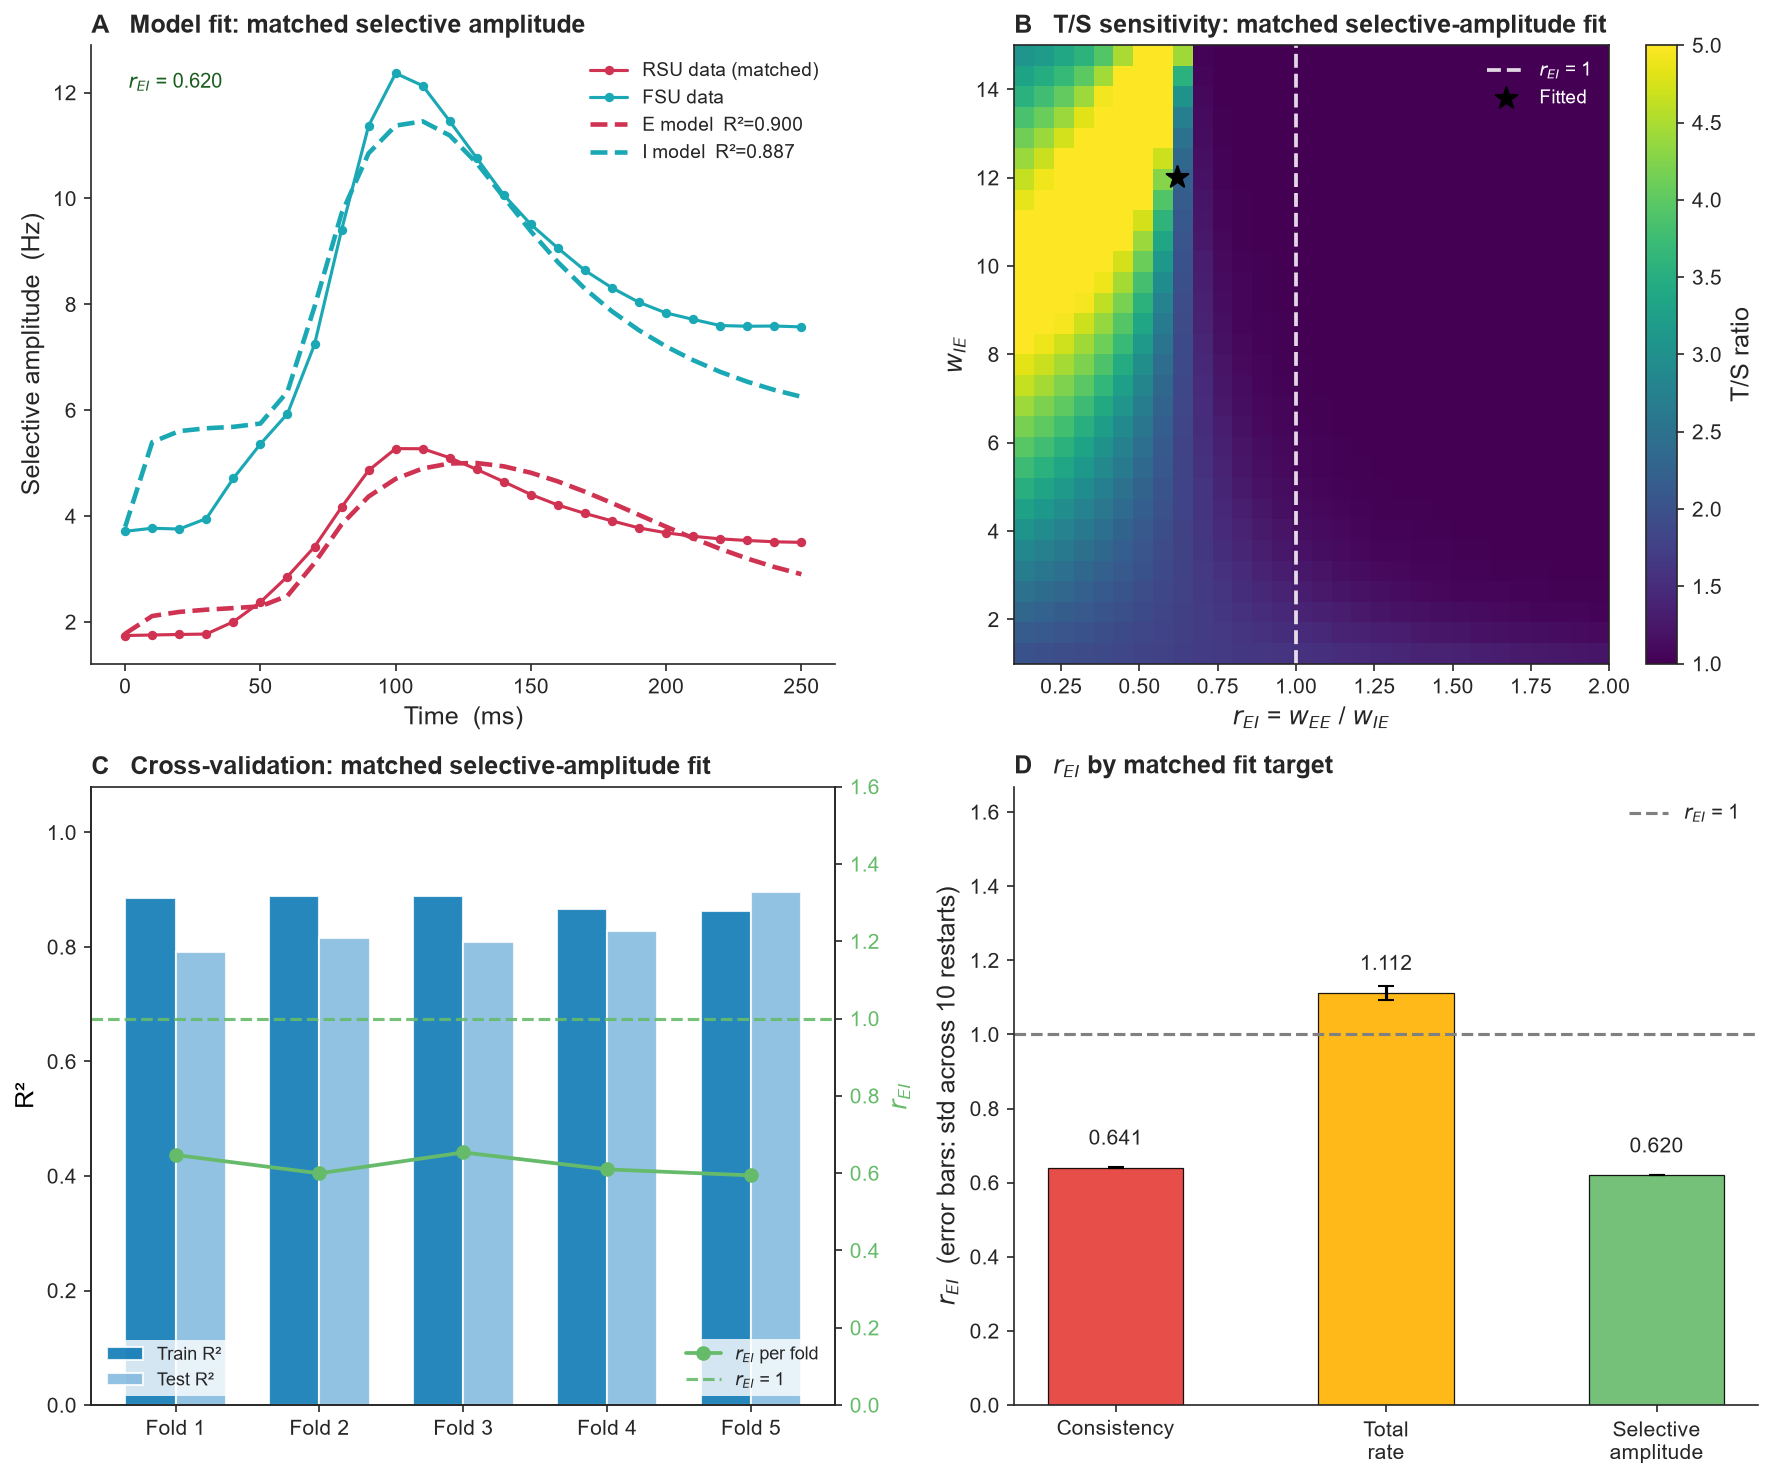

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ── Panel A: model fit to matched selective amplitude ────────────────────────
ax = axes[0, 0]
ax.plot(fit_sel_matched['t'], fit_sel_matched['data_r'], 'o-', color=COL_RSU, markersize=3.5,
        linewidth=1.5, label='RSU data (matched)')
ax.plot(fit_sel_matched['t'], fit_sel_matched['data_f'], 'o-', color=COL_FSU, markersize=3.5,
        linewidth=1.5, label='FSU data')
ax.plot(fit_sel_matched['t'], fit_sel_matched['E_sc'], '--', color=COL_RSU, linewidth=2.2,
        label=f'E model  R²={fit_sel_matched["r2_E"]:.3f}')
ax.plot(fit_sel_matched['t'], fit_sel_matched['I_sc'], '--', color=COL_FSU, linewidth=2.2,
        label=f'I model  R²={fit_sel_matched["r2_I"]:.3f}')
ax.annotate(f'$r_{{EI}}$ = {fit_sel_matched["r_EI"]:.3f}',
            xy=(0.05, 0.93), xycoords='axes fraction', fontsize=9.5, color=COL_FIT,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.set_xlabel('Time  (ms)')
ax.set_ylabel('Selective amplitude  (Hz)')
ax.set_title('A   Model fit: matched selective amplitude', loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel B: T/S sensitivity heatmap (matched selective-amplitude fit) ───────
ax = axes[0, 1]
im = ax.imshow(ts_grid_sel, origin='lower', aspect='auto',
               extent=[r_EI_range[0], r_EI_range[-1],
                       w_IE_range[0], w_IE_range[-1]],
               cmap='viridis', vmin=1, vmax=5)
ax.axvline(1.0, color='white', linestyle='--', linewidth=1.8, alpha=0.85,
           label='$r_{EI}$ = 1')
ax.scatter([fit_sel_matched['params'][0]], [fit_sel_matched['params'][1]], color='black', s=120,
           zorder=5, marker='*', label='Fitted')
plt.colorbar(im, ax=ax, label='T/S ratio')
ax.set_xlabel('$r_{EI}$ = $w_{EE}$ / $w_{IE}$')
ax.set_ylabel('$w_{IE}$')
ax.set_title('B   T/S sensitivity: matched selective-amplitude fit', loc='left',
             fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=9, labelcolor='white')

# ── Panel C: cross-validation (matched selective-amplitude fit) ─────────────
ax  = axes[1, 0]
ax2 = ax.twinx()
x   = np.arange(1, N_FOLDS + 1)
w   = 0.35
ax.bar(x - w/2, df_cv_sel['r2_train'], w, color=COL_DATA, alpha=0.85, label='Train R²')
ax.bar(x + w/2, df_cv_sel['r2_test'],  w, color=COL_TEST, alpha=0.85, label='Test R²')
ax.set_ylabel('R²', color='black')
ax.set_ylim(0, 1.08)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in x])
leg1 = ax.legend(frameon=True, fontsize=8.5, loc='lower left')
leg1.get_frame().set_facecolor('white')
leg1.get_frame().set_alpha(0.8)
leg1.get_frame().set_edgecolor('none')

ax2.plot(x, df_cv_sel['r_EI'], 'o-', color=COL_TARGET_SELECTIVE, linewidth=1.8, markersize=6,
         label='$r_{EI}$ per fold')
ax2.axhline(1.0, color=COL_TARGET_SELECTIVE, linestyle='--', linewidth=1.5, alpha=0.9,
            label='$r_{EI}$ = 1')
ax2.set_ylabel('$r_{EI}$', color=COL_TARGET_SELECTIVE)
ax2.tick_params(axis='y', labelcolor=COL_TARGET_SELECTIVE)
ax2.set_ylim(0, 1.6)
leg2 = ax2.legend(frameon=True, fontsize=8.5, loc='lower right')
leg2.get_frame().set_facecolor('white')
leg2.get_frame().set_alpha(0.8)
leg2.get_frame().set_edgecolor('none')
ax.set_title('C   Cross-validation: matched selective-amplitude fit', loc='left',
             fontweight='bold', pad=6)
ax.spines['top'].set_visible(False)

# ── Panel D: r_EI across matched fit targets ─────────────────────────────────
ax = axes[1, 1]
labels_cmp = ['Consistency', 'Total\nrate', 'Selective\namplitude']
vals_cmp   = [fit_consistency_matched['r_EI'], fit_rate_matched['r_EI'], fit_sel_matched['r_EI']]
errs_cmp   = [fit_consistency_matched['stab'].std(), fit_rate_matched['stab'].std(), fit_sel_matched['stab'].std()]
cols_cmp   = [COL_TARGET_CONSISTENCY, COL_TARGET_TOTAL_RATE, COL_TARGET_SELECTIVE]
bars = ax.bar(labels_cmp, vals_cmp, yerr=errs_cmp, capsize=4,
              color=cols_cmp, alpha=0.9, width=0.5, edgecolor='black', linewidth=0.6)
for bar, v in zip(bars, vals_cmp):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.05, f'{v:.3f}',
            ha='center', va='bottom', fontsize=10)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, label='$r_{EI}$ = 1')
ax.set_ylabel('$r_{EI}$  (error bars: std across 10 restarts)')
ax.set_ylim(0, max(vals_cmp) * 1.5)
ax.set_title('D   $r_{EI}$ by matched fit target', loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

print_figure_data(
    "Fig. 6A - model fit to matched selective amplitude",
    time_ms=fit_sel_matched['t'], rsu_data_hz=fit_sel_matched['data_r'], fsu_data_hz=fit_sel_matched['data_f'],
    e_model_fit_hz=fit_sel_matched['E_sc'], i_model_fit_hz=fit_sel_matched['I_sc'],
    r_EI_fit=fit_sel_matched['r_EI'], r2_rsu=fit_sel_matched['r2_E'], r2_fsu=fit_sel_matched['r2_I'],
)
print_figure_data(
    "Fig. 6B - T/S sensitivity heatmap, matched selective-amplitude fit",
    r_EI_range=r_EI_range, w_IE_range=w_IE_range, ts_ratio_grid=ts_grid_sel,
    fitted_r_EI=fit_sel_matched['params'][0], fitted_w_IE=fit_sel_matched['params'][1],
)
print_figure_data(
    "Fig. 6C - cross-validation, matched selective-amplitude fit",
    fold_number=x, train_r2_per_fold=df_cv_sel['r2_train'].to_numpy(),
    test_r2_per_fold=df_cv_sel['r2_test'].to_numpy(),
    r_EI_per_fold=df_cv_sel['r_EI'].to_numpy(),
    mean_r_EI=df_cv_sel['r_EI'].mean(), std_r_EI=df_cv_sel['r_EI'].std(),
)
print_figure_data(
    "Fig. 6D - r_EI by matched fit target",
    labels=labels_cmp, r_EI_values=np.array(vals_cmp), r_EI_stds=np.array(errs_cmp),
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig6_ei_model.png', bbox_inches='tight')
plt.show()

---
## Supplementary Figure

Fig. S9 — validation fits to the full (unsubsampled) RSU pool, matched-
vs-full r_EI comparison across all three fit targets, r_EI stability across
restarts, and w_II bound sensitivity.


Fig. S9A - validation: full-pool selective-amplitude fit

--- time_ms ---
shape=(26,)
[  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100. 110. 120. 130. 140. 150. 160. 170. 180. 190.]
...[26 elements total]

--- rsu_data_hz ---
shape=(26,)
[1.750308 1.762085 1.773598 1.782285 1.998374 2.349364 2.821646 3.389837 4.139697 4.835166 5.248112 5.25964  5.104295 4.8943   4.667004 4.430704 4.235762 4.076564 3.937681 3.808546]
...[26 elements total]

--- fsu_data_hz ---
shape=(26,)
[ 3.713026  3.771505  3.756008  3.953011  4.714147  5.362331  5.934358  7.242083  9.404095 11.372108 12.36476  12.131179 11.46066  10.762631 10.066233  9.509681  9.061917  8.64043   8.311727
  8.038127]
...[26 elements total]

--- e_model_fit_hz ---
shape=(26,)
[1.785401 2.10855  2.177898 2.214477 2.240173 2.269639 2.462182 3.080873 3.816468 4.350061 4.687705 4.886642 4.983224 4.994511 4.934545 4.819705 4.665161 4.483113 4.283093 4.072821]
...[26 elements total]

--- i_model_fit_hz ---
shape=(26,)
[ 3.799543  5.

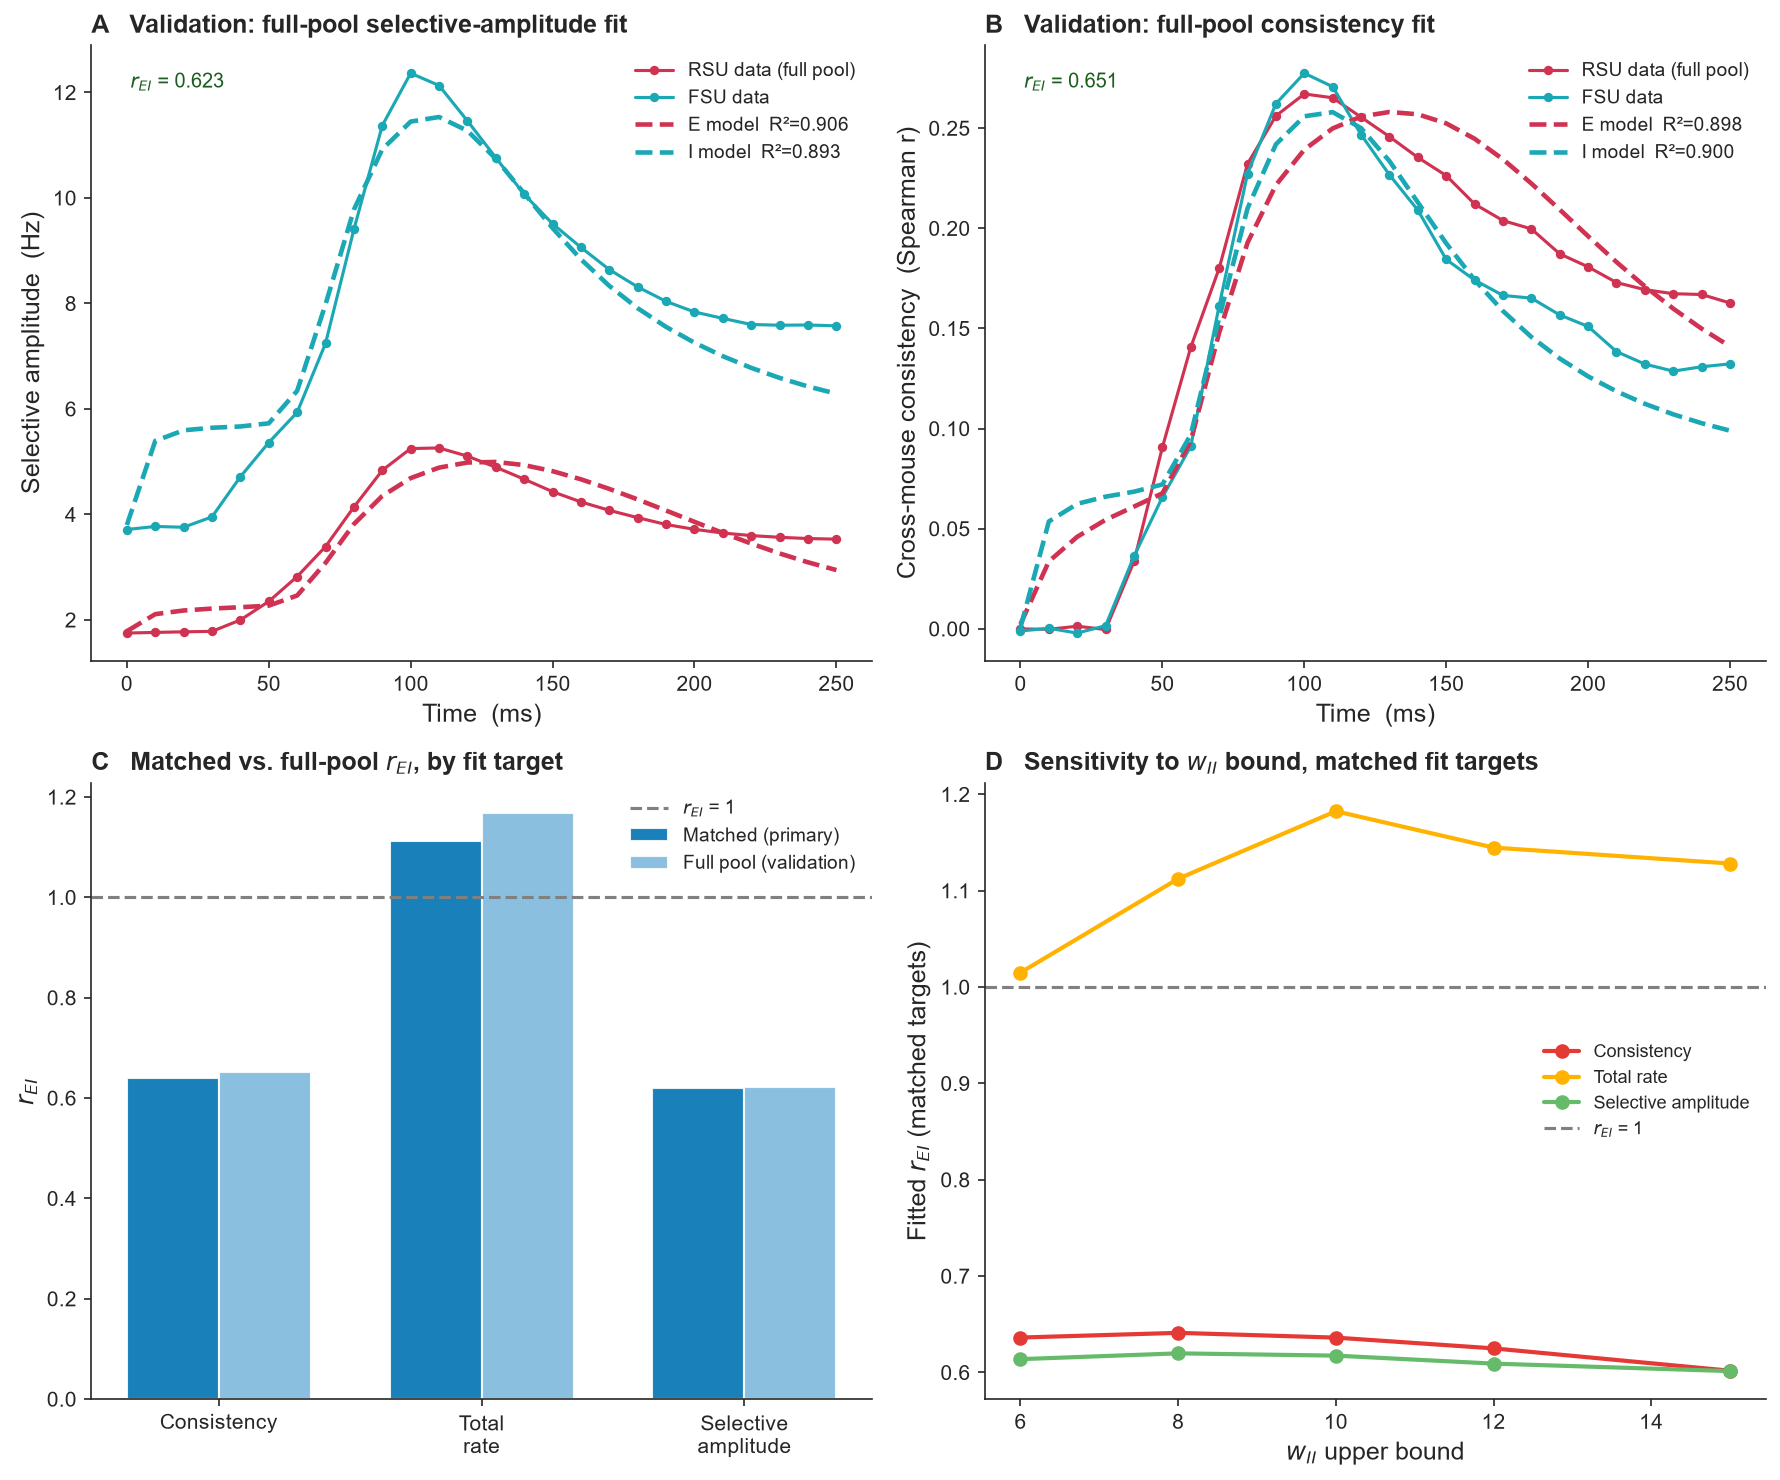

In [11]:
fig_s9, axes = plt.subplots(2, 2, figsize=(12, 10))

# ── Panel A: full-pool selective-amplitude fit (validation) ─────────────────
ax = axes[0, 0]
ax.plot(fit_sel_full['t'], fit_sel_full['data_r'], 'o-', color=COL_RSU, markersize=3.5,
        linewidth=1.5, label='RSU data (full pool)')
ax.plot(fit_sel_full['t'], fit_sel_full['data_f'], 'o-', color=COL_FSU, markersize=3.5,
        linewidth=1.5, label='FSU data')
ax.plot(fit_sel_full['t'], fit_sel_full['E_sc'], '--', color=COL_RSU, linewidth=2.2,
        label=f'E model  R²={fit_sel_full["r2_E"]:.3f}')
ax.plot(fit_sel_full['t'], fit_sel_full['I_sc'], '--', color=COL_FSU, linewidth=2.2,
        label=f'I model  R²={fit_sel_full["r2_I"]:.3f}')
ax.annotate(f'$r_{{EI}}$ = {fit_sel_full["r_EI"]:.3f}', xy=(0.05, 0.93), xycoords='axes fraction',
            fontsize=9.5, color=COL_FIT,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.set_xlabel('Time  (ms)')
ax.set_ylabel('Selective amplitude  (Hz)')
ax.set_title('A   Validation: full-pool selective-amplitude fit', loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel B: full-pool consistency fit (validation) ──────────────────────────
ax = axes[0, 1]
ax.plot(fit_consistency_full['t'], fit_consistency_full['data_r'], 'o-', color=COL_RSU, markersize=3.5,
        linewidth=1.5, label='RSU data (full pool)')
ax.plot(fit_consistency_full['t'], fit_consistency_full['data_f'], 'o-', color=COL_FSU, markersize=3.5,
        linewidth=1.5, label='FSU data')
ax.plot(fit_consistency_full['t'], fit_consistency_full['E_sc'], '--', color=COL_RSU, linewidth=2.2,
        label=f'E model  R²={fit_consistency_full["r2_E"]:.3f}')
ax.plot(fit_consistency_full['t'], fit_consistency_full['I_sc'], '--', color=COL_FSU, linewidth=2.2,
        label=f'I model  R²={fit_consistency_full["r2_I"]:.3f}')
ax.annotate(f'$r_{{EI}}$ = {fit_consistency_full["r_EI"]:.3f}', xy=(0.05, 0.93), xycoords='axes fraction',
            fontsize=9.5, color=COL_FIT,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.set_xlabel('Time  (ms)')
ax.set_ylabel('Cross-mouse consistency  (Spearman r)')
ax.set_title('B   Validation: full-pool consistency fit', loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel C: matched vs. full r_EI, by fit target ────────────────────────────
ax = axes[1, 0]
labels_mf = ['Consistency', 'Total\nrate', 'Selective\namplitude']
matched_vals = [fit_consistency_matched['r_EI'], fit_rate_matched['r_EI'], fit_sel_matched['r_EI']]
full_vals    = [fit_consistency_full['r_EI'],    fit_rate_full['r_EI'],    fit_sel_full['r_EI']]
xm = np.arange(3)
wm = 0.35
ax.bar(xm - wm/2, matched_vals, wm, color=COL_DATA, alpha=0.9, label='Matched (primary)')
ax.bar(xm + wm/2, full_vals,    wm, color=COL_TEST, alpha=0.9, label='Full pool (validation)')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, label='$r_{EI}$ = 1')
ax.set_xticks(xm)
ax.set_xticklabels(labels_mf)
ax.set_ylabel('$r_{EI}$')
ax.set_title('C   Matched vs. full-pool $r_{EI}$, by fit target', loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel D: w_II upper bound sensitivity (matched fit targets) ─────────────
def w_ii_sensitivity(target_rsu, target_fsu, w_II_bounds_test):
    t_a, a_r, a_r_n, t_b, a_f, a_f_n = prep_curves(ts_rsu, target_rsu, ts_fsu, target_fsu)

    def loss_fn(params):
        try:
            E, I = simulate(params, t_a)
            E_n  = (E - E.min()) / (E.max() - E.min() + 1e-8)
            I_n  = (I - I.min()) / (I.max() - I.min() + 1e-8)
            return np.mean((E_n - a_r_n)**2) + np.mean((I_n - a_f_n)**2)
        except Exception:
            return 1e6

    r_EI_vals = []
    for ub in w_II_bounds_test:
        bounds_test = BOUNDS[:3] + [(0.0, ub)] + BOUNDS[4:]
        try:
            res = minimize(loss_fn, x0_informed, method='L-BFGS-B', bounds=bounds_test,
                           options={'maxiter': 2000, 'ftol': 1e-12})
            r_EI_vals.append(res.x[0])
        except Exception:
            r_EI_vals.append(np.nan)
    return r_EI_vals

w_II_bounds_test = [6.0, 8.0, 10.0, 12.0, 15.0]
r_EI_at_bounds_consistency = w_ii_sensitivity(mc_rsu_matched, mc_fsu, w_II_bounds_test)
r_EI_at_bounds_rate        = w_ii_sensitivity(rate_rsu_matched, rate_fsu, w_II_bounds_test)
r_EI_at_bounds_selective   = w_ii_sensitivity(sel_rsu_matched, sel_fsu, w_II_bounds_test)

ax = axes[1, 1]
ax.plot(w_II_bounds_test, r_EI_at_bounds_consistency, 'o-', color=COL_TARGET_CONSISTENCY,
        linewidth=2, markersize=6, label='Consistency')
ax.plot(w_II_bounds_test, r_EI_at_bounds_rate, 'o-', color=COL_TARGET_TOTAL_RATE,
        linewidth=2, markersize=6, label='Total rate')
ax.plot(w_II_bounds_test, r_EI_at_bounds_selective, 'o-', color=COL_TARGET_SELECTIVE,
        linewidth=2, markersize=6, label='Selective amplitude')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, label='$r_{EI}$ = 1')
ax.set_xlabel('$w_{II}$ upper bound')
ax.set_ylabel('Fitted $r_{EI}$ (matched targets)')
ax.set_title('D   Sensitivity to $w_{II}$ bound, matched fit targets', loc='left',
             fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=8.5)
ax.spines[['top', 'right']].set_visible(False)

print_figure_data(
    "Fig. S9A - validation: full-pool selective-amplitude fit",
    time_ms=fit_sel_full['t'], rsu_data_hz=fit_sel_full['data_r'], fsu_data_hz=fit_sel_full['data_f'],
    e_model_fit_hz=fit_sel_full['E_sc'], i_model_fit_hz=fit_sel_full['I_sc'],
    r_EI_fit=fit_sel_full['r_EI'], r2_rsu=fit_sel_full['r2_E'], r2_fsu=fit_sel_full['r2_I'],
)
print_figure_data(
    "Fig. S9B - validation: full-pool consistency fit",
    time_ms=fit_consistency_full['t'], rsu_data=fit_consistency_full['data_r'],
    fsu_data=fit_consistency_full['data_f'], e_model_fit=fit_consistency_full['E_sc'],
    i_model_fit=fit_consistency_full['I_sc'], r_EI_fit=fit_consistency_full['r_EI'],
    r2_rsu=fit_consistency_full['r2_E'], r2_fsu=fit_consistency_full['r2_I'],
)
print_figure_data(
    "Fig. S9C - matched vs. full r_EI, by fit target",
    labels=labels_mf, r_EI_matched=np.array(matched_vals), r_EI_full=np.array(full_vals),
)
print_figure_data(
    "Fig. S9D - sensitivity of fitted r_EI to w_II upper bound, matched fit targets",
    w_II_upper_bound_tested=np.array(w_II_bounds_test),
    r_EI_at_bound_consistency=np.array(r_EI_at_bounds_consistency),
    r_EI_at_bound_total_rate=np.array(r_EI_at_bounds_rate),
    r_EI_at_bound_selective_amplitude=np.array(r_EI_at_bounds_selective),
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'figS9.png', bbox_inches='tight')
plt.show()